# Bitcoin Price Forecasting and SHAP Explainability

This tutorial demonstrates how to build a real-time forecasting model for Bitcoin prices using data from the CoinGecko API, and interpret its predictions using SHAP (SHapley Additive exPlanations). 

We cover:
- Data ingestion and preprocessing
- Time series model training
- SHAP-based interpretation of feature contributions

1. Introduction (Markdown)

2. Setup & Imports

3. Load Preprocessed Data (from data/raw/hourly_90d or daily_max)

4. Feature Engineering
➜ (Stop and move utility functions to src/ if needed)

5. Model Development
➜ Choose one model: start with XGBoostRegressor for simplicity
➜ Add Prophet or ARIMA next

6. SHAP Analysis

7. Evaluation & Interpretation

8. Conclusion

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

## 1. Imports and Setup

In [23]:
# Add src/ to path
import sys
sys.path.append("src")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from datetime import datetime

# Load environment variables
load_dotenv()

# For modeling
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import shap


from ingestion.fetch_data import fetch_market_chart_data
from ingestion.fetch_data import load_realtime_btc_data


from preprocessing.eda_hourly_data import (
    plot_price_over_time,
    plot_volume_over_time,
    plot_distribution,
    plot_hourly_average
)


## 2. Load Real-Time Bitcoin Price Data (Hourly)

We now fetch hourly-level Bitcoin price data from the CoinGecko API for the past 90 days. This data includes price, market cap, and volume, and is returned as a clean DataFrame via our wrapper `load_realtime_btc_data()`.

This gives us approximately 2,160 hourly records, sufficient for training a forecasting model with meaningful patterns.



In [18]:
# Fetch real-time hourly Bitcoin data for the past 90 days
df_hourly = load_realtime_btc_data(days=90)
df_hourly.head()

,timestamp,price,market_cap,volume
0,2025-02-01 00:03:41.032,102404.933761,2.029227e+12,3.736614e+10
1,2025-02-01 01:03:55.213,102470.384029,2.030933e+12,4.248330e+10
2,2025-02-01 02:03:53.898,102512.466987,2.032432e+12,4.624888e+10
3,2025-02-01 03:02:18.060,102403.779773,2.031287e+12,4.604370e+10
4,2025-02-01 04:04:00.119,102249.729376,2.026640e+12,3.721985e+10


In [19]:
df_hourly.shape

(2160, 4)

## 3 Exploratory Data Analysis (EDA) – Key Plots

We now explore the real-time hourly Bitcoin data using a few key visualizations. This helps us understand price dynamics, volatility, volume trends, and seasonal patterns.

The complete set of EDA utilities is implemented in `src/preprocessing/eda_hourly_data.py`.

In addition to the plots shown below, that module includes:
- Multiple rolling average overlays
- Boxplots by hour of day
- Correlation heatmaps
- Scatter plots of price vs volume/market cap
- Histograms of value distributions

Only a subset is shown here to keep the tutorial focused.

### 3.1 Basic time series view

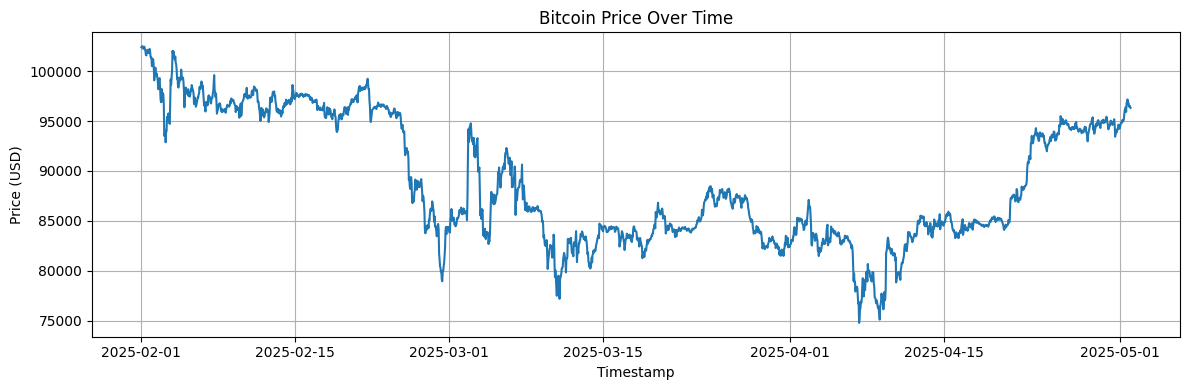

In [26]:
plot_price_over_time(df_hourly)

### 3.2 Trading volume over time

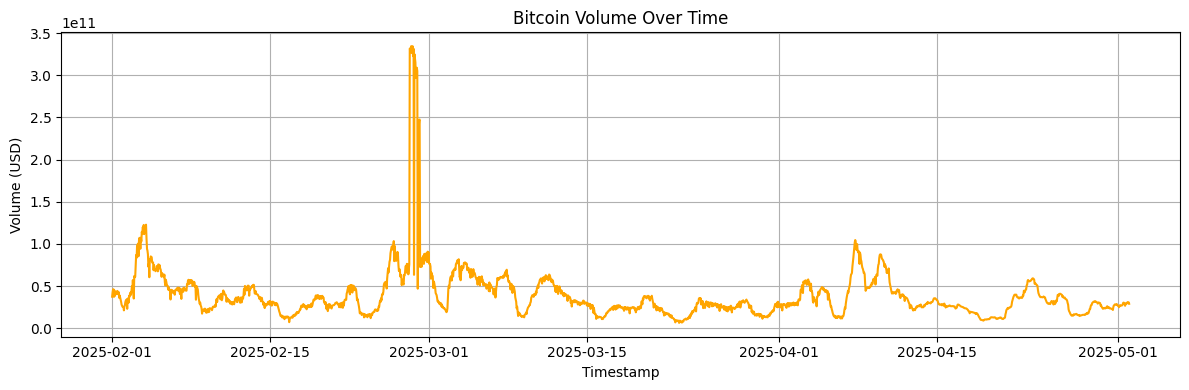

In [27]:
plot_volume_over_time(df_hourly)

### 3.3 Distribution of price values

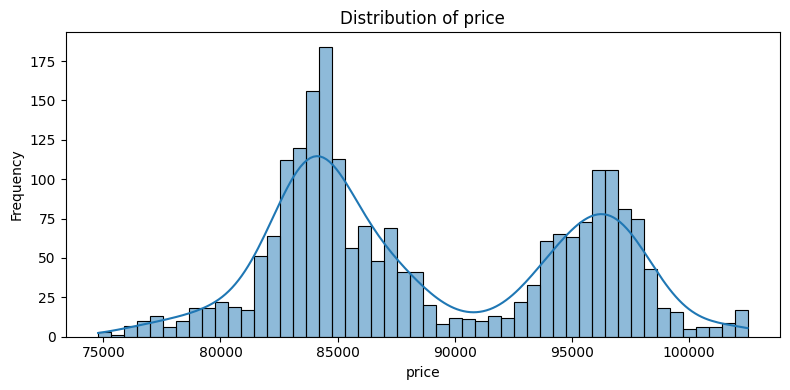

In [29]:
plot_distribution(df_hourly, column="price")

### 3.4 Seasonality: average price by hour of day

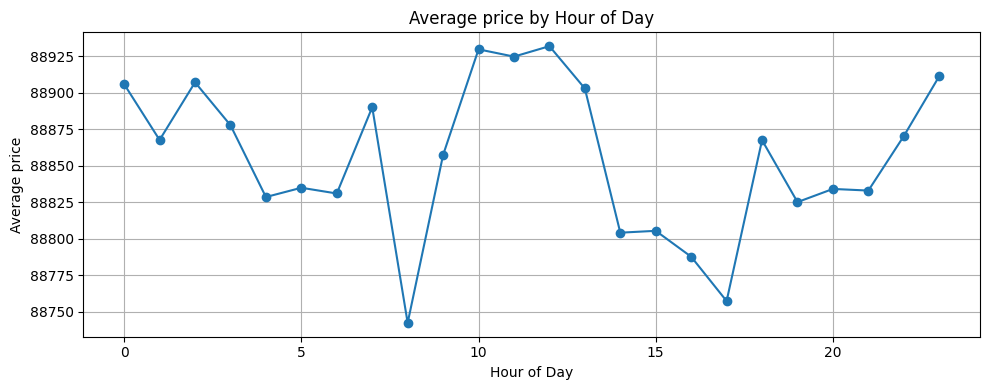

In [30]:
plot_hourly_average(df_hourly, column="price")

### 3.5 Key Observations from Hourly EDA

1. **Bitcoin Price Over Time**
   - The price exhibits substantial volatility over the 90-day window.
   - A significant downward trend is visible around mid-February to late March, followed by a steep rebound in mid-April.
   - The price recovered to previous highs toward the end of April, suggesting a potential cyclical pattern.

2. **Bitcoin Volume Over Time**
   - Volume spikes are clearly episodic — notably around early March.
   - Most of the volume stays within a relatively low baseline range, with extreme outliers indicating periods of heavy trading.
   - These spikes may align with market-moving news or speculative activity.

3. **Distribution of Price**
   - The distribution of price is **bimodal**, with one peak centered around $84,000–$86,000 and another around $94,000–$96,000.
   - This supports the presence of two dominant regimes or market conditions (e.g., accumulation vs. breakout).
   - The long left tail suggests occasional sharp drops — possibly flash crashes or corrections.

4. **Hourly Seasonality in Price**
   - While fairly stable across hours, there is a slight increase in average price around **10 AM and 11 AM UTC**, possibly correlating with active market windows in overlapping time zones (Europe/Asia).
   - A noticeable dip is observed around 13–15 UTC, which could relate to liquidity or institutional trading cycles.

---

These insights help guide feature engineering decisions, such as using lag features, rolling statistics, and even time-of-day signals for forecasting.


## 3.6 Stationarity Check

Before deciding on a time series model, we assess whether the Bitcoin price data is stationary — that is, whether its statistical properties (mean, variance) remain constant over time.

We use:
- **Rolling statistics** to visually inspect trends and volatility
- The **Augmented Dickey-Fuller (ADF) test** to formally test for stationarity

Note: While classical models like ARIMA require stationarity, modern models like XGBoost and Prophet can model non-stationary series directly.

In [5]:
class Template:
    """
    Brief imperative description of what the class does in one line, if needed.
    """
    def __init__(self):
        pass
    
    def method1(self, arg1:int) -> None:
        """
        Brief imperative description of what the method does in one line.

        You can elaborate more in the method docstring in this section, for e.g. explaining 
        the formula/algorithm. Every method/function should have a docstring, typehints and include the
        parameters and return as follows:

        :param arg1: description of arg1
        :return: description of return
        """
        # Code bloks go here.
        # Make sure to include comments to explain what the code is doing.
        # No empty lines between code blocks.
        pass


def template_function(arg1:int) -> None:
    """
    Brief imperative description of what the function does in one line.

    You can elaborate more in the function docstring in this section, for e.g. explaining 
    the formula/algorithm. Every function should have a docstring, typehints and include the
    parameters and return as follows:

    :param arg1: description of arg1
    :return: description of return
    """
    # Code bloks go here.
    # Make sure to include comments to explain what the code is doing.
    # No empty lines between code blocks.
    pass


## The flow should be highlighted using headings in markdown
```
# Level 1
## Level 2
### Level 3
```